In [ ]:
# =========================
# CELL 1: IMPORT LIBRARIES
# =========================

import os                      # For file and folder path operations
import cv2                     # For reading and resizing images
import torch                   # Main PyTorch library
import torch.nn as nn          # Neural network layers and loss functions
import torch.optim as optim    # Optimizers like Adam
import pandas as pd            # For reading labels.txt as a table

from torch.utils.data import Dataset, DataLoader, random_split  # Dataset and DataLoader utilities
from google.colab import drive                                  # To mount Google Drive in Colab

In [2]:
# =========================
# CELL 2: MOUNT GOOGLE DRIVE
# =========================

# This will ask permission to access your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================
# CELL 3: DEFINE FILE PATHS
# =========================

# Base folder where your OCR dataset is stored
base_path = "/content/drive/MyDrive/Kannada_OCR_Dataset/dataset"

# Full path to the labels file
labels_path = os.path.join(base_path, "labels.txt")

# Full path to the images folder
image_folder = os.path.join(base_path, "images")

# Path where trained model will be saved
model_save_path = "/content/drive/MyDrive/crnn_base.pth"

In [4]:
# =========================
# CELL 4: CHECK PATHS
# =========================

print("Labels file exists:", os.path.exists(labels_path))
print("Image folder exists:", os.path.exists(image_folder))
print("Number of images:", len(os.listdir(image_folder)))

Labels file exists: True
Image folder exists: True
Number of images: 5000


In [5]:
# =========================
# CELL 5: READ LABELS FILE
# =========================

# Read labels.txt
# sep="\t" means columns are separated by tab
train_df = pd.read_csv(
    labels_path,
    sep="\t",
    header=None,
    names=["filename", "text"],
    keep_default_na=False
)

# Show first few rows
print(train_df.head())

# Print total number of samples
print("Total samples:", len(train_df))

    filename       text
0  img_0.png     ಮಾಹಿತಿ
1  img_1.png       ಗಣಿತ
2  img_2.png  ಕಂಪ್ಯೂಟರ್
3  img_3.png  ಕಂಪ್ಯೂಟರ್
4  img_4.png       ಜನತೆ
Total samples: 5000


In [6]:
# =========================
# CELL 6: BUILD CHARACTER VOCABULARY
# =========================

# Combine all words into one long string
all_text = "".join(train_df["text"].tolist())

# Get unique characters and sort them
chars = sorted(list(set(all_text)))

# Create mapping: character -> number
# NOTE: 0 is reserved for CTC blank token
char_to_idx = {c: i + 1 for i, c in enumerate(chars)}

# Create reverse mapping: number -> character
idx_to_char = {i: c for c, i in char_to_idx.items()}

# Total output classes = all characters + 1 blank token
num_classes = len(char_to_idx) + 1

print("Total unique chars:", len(chars))
print("num_classes:", num_classes)
print("Sample characters:", chars[:20])

Total unique chars: 37
num_classes: 38
Sample characters: ['ಂ', 'ಅ', 'ಆ', 'ಉ', 'ಕ', 'ಗ', 'ಜ', 'ಞ', 'ಟ', 'ಣ', 'ತ', 'ಥ', 'ದ', 'ಧ', 'ನ', 'ಪ', 'ಬ', 'ಭ', 'ಮ', 'ಯ']


In [7]:
# =========================
# CELL 7: DEFINE OCR DATASET CLASS
# =========================

class OCRDataset(Dataset):
    def __init__(self, labels_path, image_folder, char_to_idx):
        # Read labels file
        self.df = pd.read_csv(
            labels_path,
            sep="\t",
            header=None,
            names=["filename", "text"],
            keep_default_na=False
        )

        self.image_folder = image_folder
        self.char_to_idx = char_to_idx

    def __len__(self):
        # Return total number of samples
        return len(self.df)

    def text_to_labels(self, text):
        # Convert each character in text into its numeric index
        return [self.char_to_idx[c] for c in text if c in self.char_to_idx]

    def __getitem__(self, idx):
        # Get one row from labels file
        row = self.df.iloc[idx]

        img_name = row["filename"]   # Image file name
        label_text = row["text"]     # Kannada word

        # Build full image path
        img_path = os.path.join(self.image_folder, img_name)

        # Read image in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        # Resize image to fixed size expected by model
        img = cv2.resize(img, (256, 32))

        # Convert pixel values from 0-255 to 0-1
        img = img.astype("float32") / 255.0

        # Convert numpy image to torch tensor
        # unsqueeze(0) adds channel dimension -> (1, 32, 256)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

        # Convert label text into numeric tensor
        label = torch.tensor(self.text_to_labels(label_text), dtype=torch.long)

        return img, label

In [8]:
# =========================
# CELL 8: CREATE DATASET
# =========================

dataset = OCRDataset(labels_path, image_folder, char_to_idx)

print("Dataset size:", len(dataset))

# Check first sample
img, label = dataset[0]
print("Image shape:", img.shape)   # Expected: torch.Size([1, 32, 256])
print("Label tensor:", label)

Dataset size: 5000
Image shape: torch.Size([1, 32, 256])
Label tensor: tensor([19, 28, 27, 29, 11, 29])


In [9]:
# =========================
# CELL 9: TRAIN/VALIDATION SPLIT
# =========================

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 4000
Val size: 1000


In [10]:
# =========================
# CELL 10: DEFINE COLLATE FUNCTION
# =========================

def collate_fn(batch):
    images = []
    labels = []
    label_lengths = []

    for img, label in batch:
        images.append(img)               # Store image tensor
        labels.append(label)             # Store label tensor
        label_lengths.append(len(label)) # Store label length

    # Stack all images into one batch tensor
    images = torch.stack(images)

    # Concatenate all label tensors into one long tensor
    labels = torch.cat(labels)

    # Convert label lengths into tensor
    label_lengths = torch.tensor(label_lengths, dtype=torch.long)

    return images, labels, label_lengths

In [11]:
# =========================
# CELL 11: CREATE DATALOADERS
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [12]:
# =========================
# CELL 12: DEFINE CRNN MODEL
# =========================

class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()

        # CNN part: extracts features from image
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # (32,256) -> (16,128)

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)    # (16,128) -> (8,64)
        )

        # RNN part: reads image features as sequence
        self.rnn = nn.LSTM(
            input_size=128 * 8,
            hidden_size=256,
            bidirectional=True,
            batch_first=True
        )

        # Final classification layer
        self.fc = nn.Linear(256 * 2, num_classes)

    def forward(self, x):
        # Pass through CNN
        x = self.cnn(x)                 # Output shape: (B,128,8,64)

        # Get dimensions
        b, c, h, w = x.size()

        # Rearrange tensor to treat width as time dimension
        x = x.permute(0, 3, 1, 2)       # (B,64,128,8)

        # Flatten feature dimension
        x = x.contiguous().view(b, w, c * h)  # (B,64,1024)

        # Pass through BiLSTM
        x, _ = self.rnn(x)              # (B,64,512)

        # Final predictions for each time step
        x = self.fc(x)                  # (B,64,num_classes)

        return x

In [13]:
# =========================
# CELL 13: SET DEVICE, MODEL, LOSS, OPTIMIZER
# =========================

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create model and move it to device
model = CRNN(num_classes).to(device)

# CTC Loss is used for sequence recognition tasks like OCR
criterion = nn.CTCLoss(blank=0, zero_infinity=True)

# Adam optimizer updates model weights during training
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [14]:
# =========================
# CELL 14: TRAIN THE MODEL
# =========================

num_epochs = 10

for epoch in range(num_epochs):
    # -------- TRAINING PART --------
    model.train()
    train_loss = 0

    for images, labels, label_lengths in train_loader:
        # Move images and labels to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass through model
        outputs = model(images)                 # Shape: (B, T, C)

        # Convert outputs to log probabilities for CTC loss
        outputs = outputs.log_softmax(2)

        # input_lengths tells CTC how many time steps each sample has
        batch_size = images.size(0)
        input_lengths = torch.full(
            size=(batch_size,),
            fill_value=outputs.size(1),
            dtype=torch.long
        ).to(device)

        # CTC expects shape (T, B, C), so we permute outputs
        loss = criterion(
            outputs.permute(1, 0, 2),   # (T, B, C)
            labels,
            input_lengths,
            label_lengths
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Add batch loss
        train_loss += loss.item()

    # -------- VALIDATION PART --------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels, label_lengths in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            outputs = outputs.log_softmax(2)

            batch_size = images.size(0)
            input_lengths = torch.full(
                size=(batch_size,),
                fill_value=outputs.size(1),
                dtype=torch.long
            ).to(device)

            loss = criterion(
                outputs.permute(1, 0, 2),
                labels,
                input_lengths,
                label_lengths
            )

            val_loss += loss.item()

    # Print epoch result
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss:   {val_loss / len(val_loader):.4f}")
    print("-" * 40)

Epoch [1/10]
Train Loss: 3.7388
Val Loss:   3.2526
----------------------------------------
Epoch [2/10]
Train Loss: 3.0773
Val Loss:   2.9643
----------------------------------------
Epoch [3/10]
Train Loss: 2.7704
Val Loss:   2.5490
----------------------------------------
Epoch [4/10]
Train Loss: 2.1505
Val Loss:   1.7007
----------------------------------------
Epoch [5/10]
Train Loss: 1.1445
Val Loss:   0.6302
----------------------------------------
Epoch [6/10]
Train Loss: 0.4307
Val Loss:   0.3239
----------------------------------------
Epoch [7/10]
Train Loss: 0.2640
Val Loss:   0.2104
----------------------------------------
Epoch [8/10]
Train Loss: 0.1700
Val Loss:   0.1245
----------------------------------------
Epoch [9/10]
Train Loss: 0.1088
Val Loss:   0.0559
----------------------------------------
Epoch [10/10]
Train Loss: 0.0624
Val Loss:   0.0985
----------------------------------------


In [15]:
# =========================
# CELL 15: SAVE TRAINED MODEL
# =========================

torch.save(model.state_dict(), model_save_path)
print("Model saved successfully at:", model_save_path)

Model saved successfully at: /content/drive/MyDrive/crnn_base.pth


In [16]:
# =========================
# CELL 16: DEFINE DECODE FUNCTION
# =========================

def decode_batch(outputs, idx_to_char):
    # Get highest probability class at each time step
    preds = outputs.argmax(2)   # Shape: (B, T)

    decoded_texts = []

    for seq in preds:
        prev = -1
        text = ""

        for idx in seq:
            idx = idx.item()

            # Ignore repeated characters and blank token (0)
            if idx != prev and idx != 0:
                text += idx_to_char.get(idx, "")

            prev = idx

        decoded_texts.append(text)

    return decoded_texts

In [17]:
# =========================
# CELL 17: TEST MODEL PREDICTIONS
# =========================

model.eval()

# Take one batch from validation loader
images, labels, label_lengths = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = decode_batch(outputs, idx_to_char)

print("Predictions:")
print(preds[:5])

Predictions:
['ಕಂಪಯೂಟರ್', 'ಮೈಸೂರು', 'ವಿದ್ಯಾರ್ಥಿ', 'ಭಾರತ', 'ತಂತ್ರಜ್ಞಾರ']


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3221 (\N{KANNADA LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Kannada natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3202 (\N{KANNADA SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3242 (\N{KANNADA LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3247 (\N{KANNADA LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dis

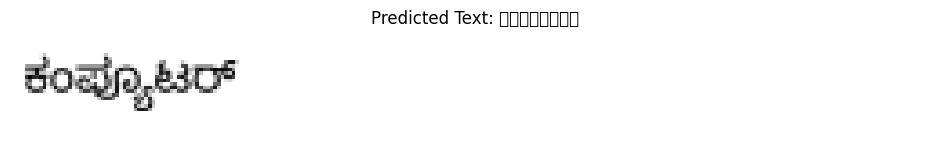

In [18]:
# =========================
# CELL 18: OPTIONAL - SHOW IMAGE AND PREDICTION
# =========================

import matplotlib.pyplot as plt

model.eval()

images, labels, label_lengths = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = decode_batch(outputs, idx_to_char)

# Show first image from batch
img = images[0].cpu().squeeze(0).numpy()

plt.figure(figsize=(12, 3))
plt.imshow(img, cmap="gray")
plt.title(f"Predicted Text: {preds[0]}")
plt.axis("off")
plt.show()

In [19]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels, label_lengths in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = decode_batch(outputs, idx_to_char)

        # reconstruct ground truth labels
        start = 0
        true_texts = []
        for length in label_lengths:
            seq = labels[start:start+length]
            text = "".join([idx_to_char[i.item()] for i in seq])
            true_texts.append(text)
            start += length

        for p, t in zip(preds, true_texts):
            if p == t:
                correct += 1
            total += 1

print("Word Accuracy:", (correct / total)*100)

Word Accuracy: 85.8


In [20]:
# =========================
# NEW CELL 19: SHOW PREDICTIONS VS ACTUAL TEXT
# =========================

model.eval()

images, labels, label_lengths = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = decode_batch(outputs, idx_to_char)

# Convert true labels back to text
true_texts = []
start = 0
for length in label_lengths:
    seq = labels[start:start + length]
    text = "".join([idx_to_char[i.item()] for i in seq])
    true_texts.append(text)
    start += length

# Print first 10 predictions
for i in range(min(10, len(preds))):
    print(f"Sample {i+1}")
    print("Actual     :", true_texts[i])
    print("Predicted  :", preds[i])
    print("-" * 40)

Sample 1
Actual     : ಕಂಪ್ಯೂಟರ್
Predicted  : ಕಂಪಯೂಟರ್
----------------------------------------
Sample 2
Actual     : ಮೈಸೂರು
Predicted  : ಮೈಸೂರು
----------------------------------------
Sample 3
Actual     : ವಿದ್ಯಾರ್ಥಿ
Predicted  : ವಿದ್ಯಾರ್ಥಿ
----------------------------------------
Sample 4
Actual     : ಭಾರತ
Predicted  : ಭಾರತ
----------------------------------------
Sample 5
Actual     : ತಂತ್ರಜ್ಞಾನ
Predicted  : ತಂತ್ರಜ್ಞಾರ
----------------------------------------
Sample 6
Actual     : ಮೈಸೂರು
Predicted  : ಮೈಸೂರು
----------------------------------------
Sample 7
Actual     : ಶಿಕ್ಷಕ
Predicted  : ಶಿಕ್ಷಕ
----------------------------------------
Sample 8
Actual     : ಪ್ರೋಗ್ರಾಮಿಂಗ್
Predicted  : ಪ್ರೋಗ್ರಾಮಿಂಗ್
----------------------------------------
Sample 9
Actual     : ವಿದ್ಯಾರ್ಥಿ
Predicted  : ವಿದಯಾರ್ಥಿ
----------------------------------------
Sample 10
Actual     : ಅಭಿವೃದ್ಧಿ
Predicted  : ಅಭಿವೃದ್ಧಿ
----------------------------------------


In [21]:
# =========================
# NEW CELL 20: PREPROCESS ONE IMAGE FOR TESTING
# =========================

def preprocess_single_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    img = cv2.resize(img, (256, 32))
    img = img.astype("float32") / 255.0
    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,32,256)

    return img

In [22]:
# =========================
# NEW CELL 21: TEST ON ONE NEW IMAGE
# =========================

# Change this path to your test image
test_img_path = "/content/drive/MyDrive/Kannada_OCR_Dataset/real_image/images/real_0089.png"

img = preprocess_single_image(test_img_path).to(device)

model.eval()
with torch.no_grad():
    outputs = model(img)
    pred_text = decode_batch(outputs, idx_to_char)[0]

print("Predicted Text:", pred_text)

Predicted Text: ಮಿಿಶಿ್ಿೆ


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3246 (\N{KANNADA LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3263 (\N{KANNADA VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3254 (\N{KANNADA LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3270 (\N{KANNADA VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


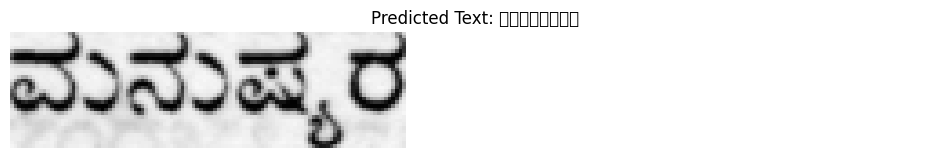

In [23]:
# =========================
# NEW CELL 22: DISPLAY TEST IMAGE
# =========================

import matplotlib.pyplot as plt

img_display = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 3))
plt.imshow(img_display, cmap="gray")
plt.title(f"Predicted Text: {pred_text}")
plt.axis("off")
plt.show()

In [24]:
# =========================
# BETTER PREPROCESSING FOR TEST IMAGE
# =========================

def preprocess_single_image_better(img_path, target_h=32, target_w=256):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    # Optional denoise
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Resize while keeping aspect ratio
    h, w = img.shape
    scale = min(target_w / w, target_h / h)

    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    resized = cv2.resize(img, (new_w, new_h))

    # White background canvas
    canvas = 255 * np.ones((target_h, target_w), dtype=np.uint8)

    # Center image vertically, left align horizontally
    y_offset = (target_h - new_h) // 2
    x_offset = 0

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    # Normalize
    canvas = canvas.astype("float32") / 255.0

    # Convert to tensor shape (1,1,32,256)
    tensor = torch.tensor(canvas, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    return tensor, canvas

In [25]:
# =========================
# IMPROVED DECODE FUNCTION
# =========================

def decode_batch_ctc(outputs, idx_to_char):
    preds = outputs.argmax(2)   # (B, T)
    decoded_texts = []

    for seq in preds:
        seq = seq.cpu().numpy().tolist()

        decoded = []
        prev = 0

        for idx in seq:
            # skip blank
            if idx == 0:
                prev = idx
                continue

            # skip repeated consecutive chars
            if idx == prev:
                continue

            decoded.append(idx_to_char.get(idx, ""))
            prev = idx

        decoded_texts.append("".join(decoded))

    return decoded_texts

Predicted Text: ಮಿಿ


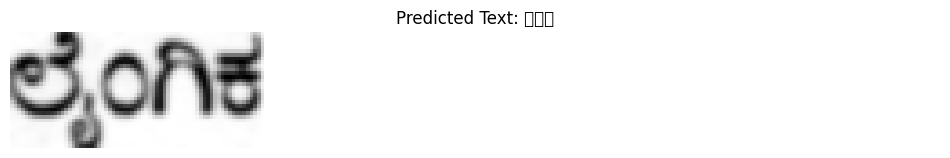

In [26]:
# =========================
# TEST ONE IMAGE WITH BETTER PREPROCESSING
# =========================

import matplotlib.pyplot as plt
import numpy as np

test_img_path = "/content/drive/MyDrive/Kannada_OCR_Dataset/real_image/images/real_0010.png"  # change this

img_tensor, processed_img = preprocess_single_image_better(test_img_path)
img_tensor = img_tensor.to(device)

model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    pred_text = decode_batch_ctc(outputs, idx_to_char)[0]

print("Predicted Text:", pred_text)

plt.figure(figsize=(12, 3))
plt.imshow(processed_img, cmap="gray")
plt.title(f"Predicted Text: {pred_text}")
plt.axis("off")
plt.show()

In [27]:
# =========================
# WORD LEVEL ACCURACY
# =========================

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels, label_lengths in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = decode_batch_ctc(outputs, idx_to_char)

        # Convert labels to text
        start = 0
        true_texts = []
        for length in label_lengths:
            seq = labels[start:start+length]
            text = "".join([idx_to_char[i.item()] for i in seq])
            true_texts.append(text)
            start += length

        for p, t in zip(preds, true_texts):
            if p == t:
                correct += 1
            total += 1

word_accuracy = correct / total
print("Word Accuracy:", word_accuracy)

Word Accuracy: 0.858


In [28]:
# =========================
# CHARACTER LEVEL ACCURACY
# =========================

correct_chars = 0
total_chars = 0

for p, t in zip(preds, true_texts):
    min_len = min(len(p), len(t))

    for i in range(min_len):
        if p[i] == t[i]:
            correct_chars += 1

    total_chars += len(t)

char_accuracy = correct_chars / total_chars
print("Character Accuracy:", char_accuracy)

Character Accuracy: 0.85


In [29]:
!pip install scikit-learn

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3242 (\N{KANNADA LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Kannada natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3254 (\N{KANNADA LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3272 (\N{KANNADA VOWEL SIGN AI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3262 (\N{KANNADA VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3221 (\N{KANNADA LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/

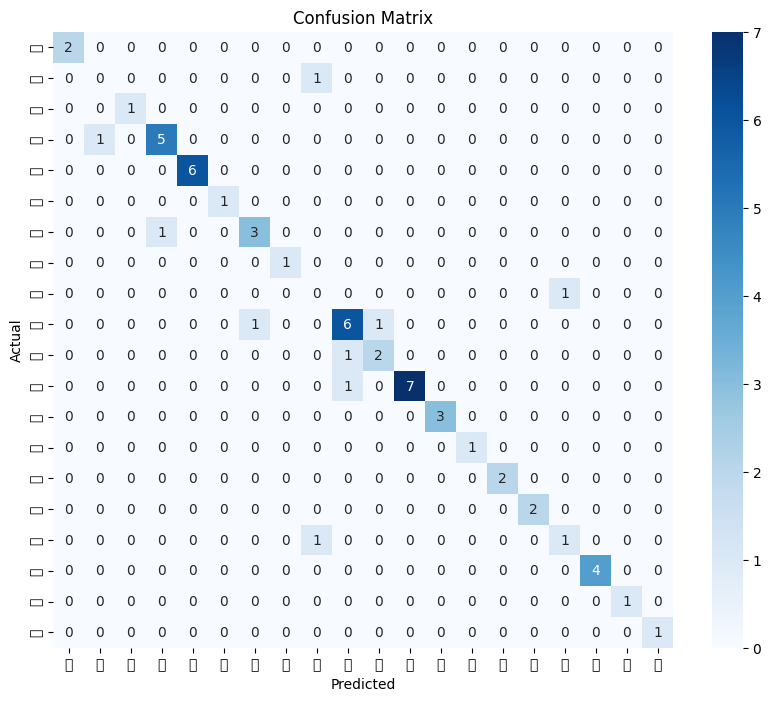

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for p, t in zip(preds, true_texts):
    min_len = min(len(p), len(t))

    for i in range(min_len):
        y_true.append(t[i])
        y_pred.append(p[i])

# Take only top characters to avoid huge matrix
labels = list(set(y_true))[:20]

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

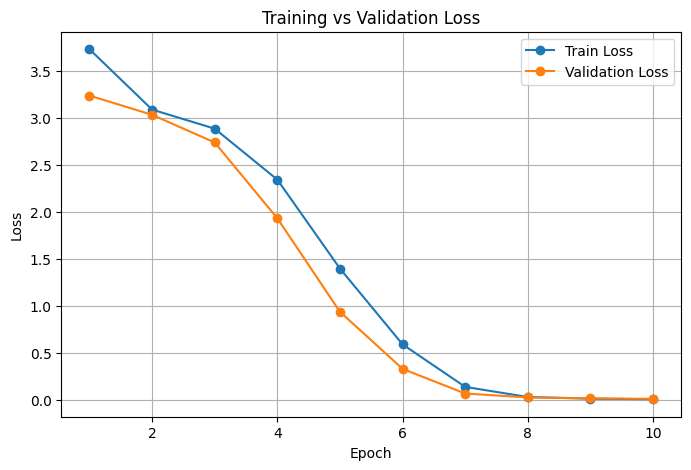

In [31]:
#Training graph
import matplotlib.pyplot as plt

train_losses = [3.7293, 3.0875, 2.8845, 2.3422, 1.3967, 0.5902, 0.1384, 0.0307, 0.0130, 0.0072]
val_losses   = [3.2363, 3.0318, 2.7376, 1.9311, 0.9366, 0.3299, 0.0677, 0.0259, 0.0167, 0.0111]

epochs = range(1, 11)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()